# 5. Forward Propagation
---
**Forward propagation** is the process of passing input data through the network, layer by layer, to produce a prediction. This is the "inference" step.

Forward propagation is the process where a neural network transforms input data into predictions or outputs. Think of it as the “thinking” phase of a neural network — when shown an input (like an image or text), forward propagation is how the network processes that information through its layers to produce a result.

In technical terms, it’s the sequential calculation that moves data from the input layer, through hidden layers, and finally to the output layer. During this journey, the data is transformed by weighted connections and activation functions, allowing the network to capture complex patterns.


<img src="./Images/forward_propagation.webp" width="800" height="800" />

## 5.1 The Forward Pass: Layer by Layer

For each layer $l$:

$$z^{[l]} = W^{[l]} \cdot a^{[l-1]} + b^{[l]}$$
$$a^{[l]} = f\left(z^{[l]}\right)$$

Where:
- $a^{[l-1]}$ = activation from the previous layer (or input $x$ for layer 1)
- $W^{[l]}$ = weight matrix for layer $l$
- $b^{[l]}$ = bias vector for layer $l$  
- $f$ = activation function
- $z^{[l]}$ = pre-activation (linear step)
- $a^{[l]}$ = post-activation

We call $z$ the **pre-activation** and $a$ the **activation**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z): return 1 / (1 + np.exp(-z))
def relu(z):    return np.maximum(0, z)

# ── Network Definition ──
# Architecture: 3 inputs → 4 hidden (ReLU) → 2 hidden (ReLU) → 1 output (Sigmoid)

layer_dims = [3, 4, 2, 1]

# Initialize weights (He initialization for ReLU — covered in Notebook 9)
def init_weights(layer_dims):
    params = {}
    for l in range(1, len(layer_dims)):
        params[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2/layer_dims[l-1])
        params[f'b{l}'] = np.zeros((layer_dims[l], 1))
    return params

params = init_weights(layer_dims)

print("Network: 3 → 4 → 2 → 1")
for l in range(1, len(layer_dims)):
    print(f"  Layer {l}: W{l} shape = {params[f'W{l}'].shape}, b{l} shape = {params[f'b{l}'].shape}")

Network: 3 → 4 → 2 → 1
  Layer 1: W1 shape = (4, 3), b1 shape = (4, 1)
  Layer 2: W2 shape = (2, 4), b2 shape = (2, 1)
  Layer 3: W3 shape = (1, 2), b3 shape = (1, 1)


In [2]:
# ── Forward Propagation ──
def forward_pass(X, params, verbose=True):
    """
    X: input, shape (n_features, n_samples)
    params: dict of W1, b1, W2, b2, ...
    """
    L = len(layer_dims) - 1  # number of layers
    cache = {'a0': X}

    for l in range(1, L + 1):
        W = params[f'W{l}']
        b = params[f'b{l}']
        a_prev = cache[f'a{l-1}']

        z = W @ a_prev + b      # linear step
        a = relu(z) if l < L else sigmoid(z)   # ReLU hidden, sigmoid output

        cache[f'z{l}'] = z
        cache[f'a{l}'] = a

        if verbose:
            print(f"Layer {l}: z{l} shape={z.shape}, a{l} shape={a.shape}  activation={'ReLU' if l<L else 'Sigmoid'}")

    return cache[f'a{L}'], cache

# Single sample input (3 features, 1 sample)
X = np.array([[0.5], [-1.2], [0.8]])   # shape (3, 1)

print("=== Forward Pass (single sample) ===")
y_hat, cache = forward_pass(X, params, verbose=True)
print(f"\nPrediction: ŷ = {y_hat[0,0]:.4f}")


=== Forward Pass (single sample) ===
Layer 1: z1 shape=(4, 1), a1 shape=(4, 1)  activation=ReLU
Layer 2: z2 shape=(2, 1), a2 shape=(2, 1)  activation=ReLU
Layer 3: z3 shape=(1, 1), a3 shape=(1, 1)  activation=Sigmoid

Prediction: ŷ = 0.5000


In [3]:
# ── Batch Forward Pass ──
# In practice we process many samples at once (vectorized)

X_batch = np.random.randn(3, 5)   # 5 samples, 3 features each

print("=== Forward Pass (batch of 5 samples) ===")
y_hat_batch, _ = forward_pass(X_batch, params, verbose=True)
print(f"\nPredictions for 5 samples: {np.round(y_hat_batch.flatten(), 3)}")


=== Forward Pass (batch of 5 samples) ===
Layer 1: z1 shape=(4, 5), a1 shape=(4, 5)  activation=ReLU
Layer 2: z2 shape=(2, 5), a2 shape=(2, 5)  activation=ReLU
Layer 3: z3 shape=(1, 5), a3 shape=(1, 5)  activation=Sigmoid

Predictions for 5 samples: [0.5   0.5   0.515 0.5   0.5  ]


## 5.2 Visualizing the Computational Graph

The forward pass builds a **computational graph** — a record of every operation.  
We'll need this graph to run **backpropagation** (going backwards through the same graph).

```
x ──→ [W1·x + b1] ──→ [ReLU] ──→ [W2·a1 + b2] ──→ [Sigmoid] ──→ ŷ ──→ Loss
        z1             a1           z2               a2
```

Every `z` and `a` computed in the forward pass gets **cached** (saved) for use in backprop.


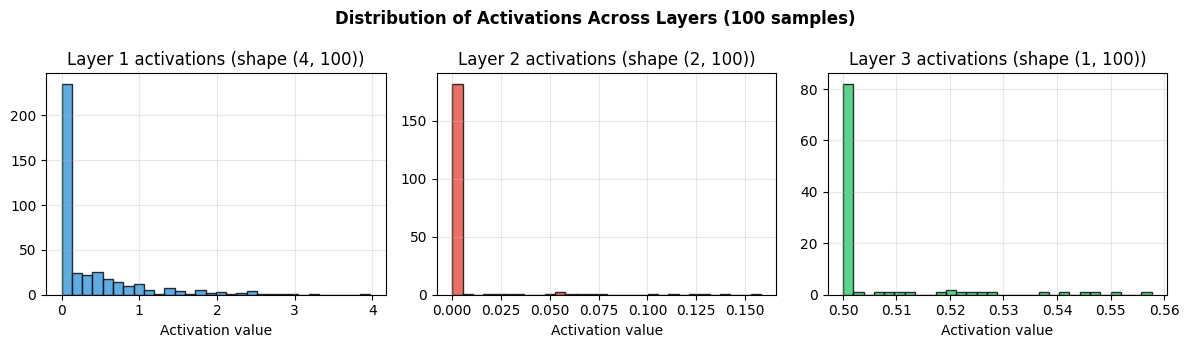

In [4]:
# Visualize activations layer by layer for a batch
X_vis = np.random.randn(3, 100)  # 100 samples
_, cache_vis = forward_pass(X_vis, params, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for i, l in enumerate([1, 2, 3]):
    a = cache_vis[f'a{l}'].flatten()
    axes[i].hist(a, bins=30, color=['#3498DB','#E74C3C','#2ECC71'][i], edgecolor='k', alpha=0.8)
    axes[i].set_title(f"Layer {l} activations (shape {cache_vis[f'a{l}'].shape})")
    axes[i].set_xlabel("Activation value")
    axes[i].grid(alpha=0.3)

plt.suptitle("Distribution of Activations Across Layers (100 samples)", fontweight='bold')
plt.tight_layout()
plt.show()


## 5.3 A Complete Forward + Loss Computation

Let's put it all together: forward pass → compute loss.


In [5]:
def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, 1-1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

# Simulate a mini dataset
np.random.seed(1)
X_data = np.random.randn(3, 20)         # 20 samples, 3 features
y_data = (np.random.rand(1, 20) > 0.5).astype(float)  # random binary labels

# Forward pass
y_hat, _ = forward_pass(X_data, params, verbose=False)

# Compute loss
loss = binary_cross_entropy(y_data, y_hat)
accuracy = np.mean((y_hat > 0.5) == y_data)

print(f"Loss:     {loss:.4f}")
print(f"Accuracy: {accuracy:.2%}")
print(f"\nNote: random weights → ~50% accuracy (as expected)")
print("Training (backprop) will improve both!")


Loss:     0.6864
Accuracy: 60.00%

Note: random weights → ~50% accuracy (as expected)
Training (backprop) will improve both!


## ✏️ Exercises

1. **Code:** Modify `forward_pass` to use tanh instead of ReLU in the hidden layers. Does the output change?
